In [1]:
from google.colab import files
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from transformers import ViTModel, ViTConfig

class VisionTransformerBinaryClassifier(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=16,
        num_channels=3,
        hidden_size=768,
        num_attention_heads=12,
        num_encoder_layers=12,
        num_decoder_layers=6,
        intermediate_size=3072,
        dropout=0.1
    ):
        super().__init__()

        # ViT Configuration
        self.config = ViTConfig(
            image_size=image_size,
            patch_size=patch_size,
            num_channels=num_channels,
            hidden_size=hidden_size,
            num_attention_heads=num_attention_heads,
            num_hidden_layers=num_encoder_layers,
            intermediate_size=intermediate_size,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout
        )

        # Encoder (ViT)
        self.encoder = ViTModel(self.config)

        # Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=num_attention_heads,
            dim_feedforward=intermediate_size,
            dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_decoder_layers
        )

        # Query embedding for decoder
        self.query_embed = nn.Parameter(torch.randn(1, 1, hidden_size))

        # Final classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, pixel_values):
        # Encode the input images
        encoder_outputs = self.encoder(pixel_values)
        encoded_features = encoder_outputs.last_hidden_state

        # Prepare query embedding for decoder
        batch_size = pixel_values.size(0)
        query_embed = self.query_embed.expand(batch_size, -1, -1)

        # Decode with self-attention and cross-attention
        decoded_features = self.decoder(
            query_embed,
            encoded_features
        )

        # Classification
        logits = self.classifier(decoded_features.squeeze(1))

        return logits

def load_pretrained_vit_classifier(checkpoint_path=None):
    """
    Initialize the model and optionally load pretrained weights
    """
    model = VisionTransformerBinaryClassifier()

    if checkpoint_path:
        state_dict = torch.load(checkpoint_path)
        model.load_state_dict(state_dict)

    return model

# Example usage
def predict_image(model, image_tensor):
    """
    Make a prediction on a single image

    Args:
        model: The VisionTransformer model
        image_tensor: Preprocessed image tensor of shape [1, 3, 224, 224]

    Returns:
        prediction: Binary prediction (0 or 1)
        probability: Confidence score
    """
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probability = output.item()
        prediction = 1 if probability >= 0.5 else 0

    return prediction, probability

# Example preprocessing function
def preprocess_image(image_path):
    """
    Preprocess an image for the model

    Args:
        image_path: Path to the image file

    Returns:
        tensor: Preprocessed image tensor
    """
    from PIL import Image
    from torchvision import transforms

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    tensor = transform(image).unsqueeze(0)

    return tensor



Saving Frame6.jpg to Frame6.jpg
Prediction: Pozitive
Confidence: 52.42%


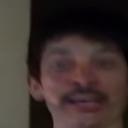

In [5]:
model = load_pretrained_vit_classifier()


uploaded = files.upload()  #pop up
image_path = list(uploaded.keys())[0]
image_tensor = preprocess_image(image_path)


prediction, confidence = predict_image(model, image_tensor)

print(f"Prediction: {'Pozitive' if prediction == 1 else 'Negative'}")
print(f"Confidence: {confidence:.2%}")
img = Image.open(image_path)
display(img)